### **4.2 Forecasting a Moving Average Process**

We will be working with **daily electricity sales data** (in GWh) from **August 2005 to November 2006**. This dataset captures electricity demand patterns over time - ideal for understanding MA behaviour.

---

**Data Overview**

- File: `AnnualElectricitySalesMA.csv`
- Date format: `yyyy-mm-dd`
- Variable: `Sales(GWh)` - daily electricity sales in giga watt hours (float)

**Source**: Adapted from [AER: Daily Contract Prices and Traded Volumes in South Australia](https://www.aer.gov.au/industry/registers/charts/daily-q1-base-contract-prices-and-traded-volumes-south-australia)

**Libraries Used**

- `statsmodels.tsa` - for building autoregressive time series models
- `matplotlib` - for visualising the data and forecasts

**Responsible AI Principles**

Before applying the model, reflect on the ethical use of data:

- Where is the data from, and who collected it?

- Are there any **privacy risks**?

- Does the data include **protected attributes** (e.g. gender, income, etc.)

- Which features are **observed, unobserved**, and what is the **outcome**?

- Could the data introduce **bias**? If so, consider how to mitigate it before modelling.

This helps ensure that our forecasting is **not only accurate**, but also **fair and responsible**.

**Model Identification Flow**

The diagram below outlines the decision process for identifying whether a time series follows an **autoregressive (AR)**, **moving average (MA)**, or **random walk** pattern. It guides you through checking for **stationarity**, examining **autocorrelation** via ACF and PACF plots, and selecting the appropriate model based on where the autocorrelations become non-significant.

<img src="Id_MAq_process.png" alt="Autoregression Model Identification" width="700">

**Step 1: Import all the libraries, read the data and explore observed data**


In [2]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller         # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf     # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf    # for partial autocorrelation plots

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Read the dataset
df = pd.read_csv("./data/AnnualElectricitySalesMA.csv", parse_dates=['Date'], index_col='Date')

In [7]:
# Display the first few rows of the dataset
df.head()

,Sales
Date,
2005-07-02,505.0
2005-07-03,508.1
2005-07-04,514.8
2005-07-05,535.4
2005-07-06,548.7


Plot the data to verify whether any evident patterns can be observed.

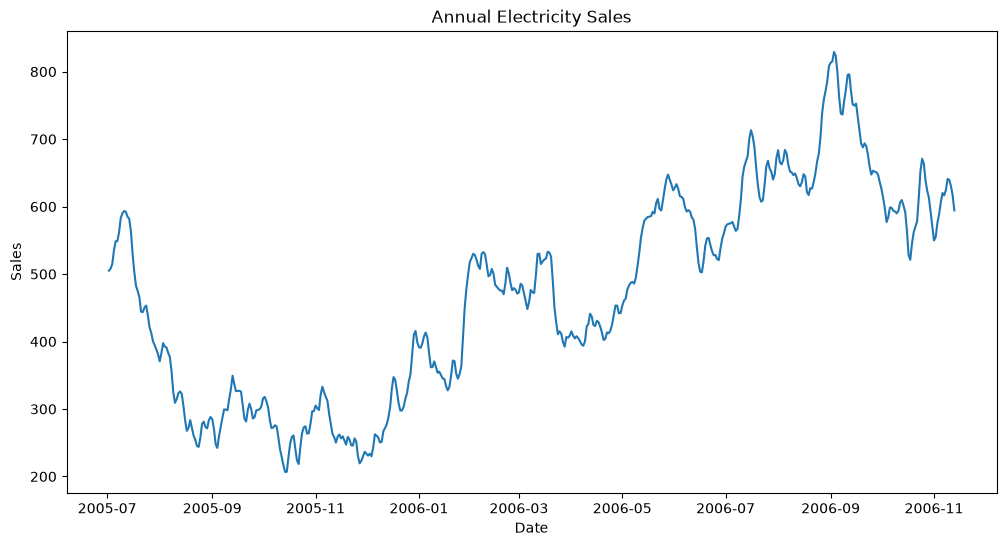

In [8]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Annual Electricity Sales')
plt.show()

**What do you observe in this graph?**
- Is it stationary process?
- Does it show a trend?
- Does it show seasonality?

**Step 2: Test for Stationarity**

If you look at the graph, it gives us an idea that it is not a stationary process but we still need to use ADF test to be sure.

In [15]:
ADF_result = adfuller(df['Sales'])
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic      -1.5124
p-value             0.5274


We can see that the ADF test result ($p\gt0.05$) shows us that the time series is not stationary. We cannot reject the null hypothesis that a **unit root exists**.

---

**Importance of performing the ADF test**

---

**`regression` parameter in adfuller()**

**Step 3: First-order Differencing**

Since the time series is not stationary, we apply transformation (first-order differencing).